In [ ]:
import os
from google.colab import files

# Create directories
for scene in ['lego', 'chair', 'drums']:
    os.makedirs(f'/content/scenes/{scene}', exist_ok=True)

# Upload LEGO images
print('📸 Upload LEGO images (select all 10-15 at once):')
uploaded = files.upload()
for fname, data in uploaded.items():
    with open(f'/content/scenes/lego/{fname}', 'wb') as f:
        f.write(data)
print(f'✅ Lego: {len(uploaded)} images uploaded')

📸 Upload LEGO images (select all 10-15 at once):


Saving r_31.png to r_31.png
Saving r_32.png to r_32.png
Saving r_63.png to r_63.png
Saving r_75.png to r_75.png
Saving r_106.png to r_106.png
Saving r_107.png to r_107.png
Saving r_163.png to r_163.png
Saving r_167.png to r_167.png
✅ Lego: 8 images uploaded


In [ ]:
print('📸 Upload CHAIR images:')
uploaded = files.upload()
for fname, data in uploaded.items():
    with open(f'/content/scenes/chair/{fname}', 'wb') as f:
        f.write(data)
print(f'✅ Chair: {len(uploaded)} images uploaded')

📸 Upload CHAIR images:


Saving r_2.png to r_2.png
Saving r_3.png to r_3.png
Saving r_4.png to r_4.png
Saving r_5.png to r_5.png
Saving r_6.png to r_6.png
Saving r_7.png to r_7.png
Saving r_8.png to r_8.png
✅ Chair: 7 images uploaded


In [ ]:
import os, glob

# Check common upload locations
for base in ['/content', '/content/scenes', '/content/drive/MyDrive']:
    if os.path.exists(base):
        files = [f for f in os.listdir(base) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]
        if files:
            print(f'FOUND {len(files)} images in: {base}')
            for f in files[:5]:
                print(f'  {f}')
            if len(files) > 5:
                print(f'  ... and {len(files)-5} more')

# Also check if scenes folder exists and what's inside
print('\n=== /content/scenes/ contents ===')
if os.path.exists('/content/scenes'):
    for root, dirs, files in os.walk('/content/scenes'):
        depth = root.replace('/content/scenes', '').count(os.sep)
        if depth <= 2:
            print(f'  {root}/ ({len(files)} files)')
            for f in files[:3]:
                print(f'    {f}')
else:
    print('  /content/scenes/ does not exist')

FOUND 15 images in: /content
  r_8.png
  r_107.png
  r_163.png
  r_167.png
  r_4.png
  ... and 10 more

=== /content/scenes/ contents ===
  /content/scenes/ (0 files)
  /content/scenes/lego/ (8 files)
    r_107.png
    r_163.png
    r_167.png
  /content/scenes/drums/ (0 files)
  /content/scenes/chair/ (7 files)
    r_8.png
    r_4.png
    r_2.png


In [ ]:
import os, glob, shutil

# See what's already in each folder
print('=== Already in scenes/ ===')
for scene in ['lego', 'chair']:
    files = sorted(os.listdir(f'/content/scenes/{scene}'))
    print(f'{scene}: {files}')

# See what's still loose in /content/
loose = sorted([f for f in os.listdir('/content') if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
print(f'\n=== Still in /content/ ({len(loose)} files) ===')
for f in loose:
    print(f'  {f}')

# Move: r_2 to r_8 → chair, rest → lego
chair_names = ['r_2.png', 'r_3.png', 'r_4.png', 'r_5.png', 'r_6.png', 'r_7.png', 'r_8.png']
moved_chair = 0
moved_lego = 0

for f in loose:
    src = f'/content/{f}'
    if f in chair_names:
        dst = f'/content/scenes/chair/{f}'
    else:
        dst = f'/content/scenes/lego/{f}'

    if not os.path.exists(dst):
        shutil.move(src, dst)
        print(f'  Moved {f} → {"chair" if f in chair_names else "lego"}')
    else:
        print(f'  {f} already exists in destination, skipping')

# Final count
print('\n=== FINAL STATE ===')
for scene in ['lego', 'chair']:
    files = sorted(os.listdir(f'/content/scenes/{scene}'))
    print(f'{scene}: {len(files)} images → {files}')

=== Already in scenes/ ===
lego: ['r_106.png', 'r_107.png', 'r_163.png', 'r_167.png', 'r_31.png', 'r_32.png', 'r_63.png', 'r_75.png']
chair: ['r_2.png', 'r_3.png', 'r_4.png', 'r_5.png', 'r_6.png', 'r_7.png', 'r_8.png']

=== Still in /content/ (15 files) ===
  r_106.png
  r_107.png
  r_163.png
  r_167.png
  r_2.png
  r_3.png
  r_31.png
  r_32.png
  r_4.png
  r_5.png
  r_6.png
  r_63.png
  r_7.png
  r_75.png
  r_8.png
  r_106.png already exists in destination, skipping
  r_107.png already exists in destination, skipping
  r_163.png already exists in destination, skipping
  r_167.png already exists in destination, skipping
  r_2.png already exists in destination, skipping
  r_3.png already exists in destination, skipping
  r_31.png already exists in destination, skipping
  r_32.png already exists in destination, skipping
  r_4.png already exists in destination, skipping
  r_5.png already exists in destination, skipping
  r_6.png already exists in destination, skipping
  r_63.png already e

In [ ]:
from PIL import Image

for scene in ['lego', 'chair']:
    print(f'\n=== {scene} ===')
    path = f'/content/scenes/{scene}'
    for f in sorted(os.listdir(path)):
        fpath = os.path.join(path, f)
        try:
            img = Image.open(fpath)
            print(f'  ✅ {f}: {img.size[0]}x{img.size[1]}, mode={img.mode}')
        except Exception as e:
            print(f'  ❌ {f}: CORRUPT — {e}')


=== lego ===
  ✅ r_106.png: 800x800, mode=RGBA
  ✅ r_107.png: 800x800, mode=RGBA
  ✅ r_163.png: 800x800, mode=RGBA
  ✅ r_167.png: 800x800, mode=RGBA
  ✅ r_31.png: 800x800, mode=RGBA
  ✅ r_32.png: 800x800, mode=RGBA
  ✅ r_63.png: 800x800, mode=RGBA
  ✅ r_75.png: 800x800, mode=RGBA

=== chair ===
  ✅ r_2.png: 800x800, mode=RGBA
  ✅ r_3.png: 800x800, mode=RGBA
  ✅ r_4.png: 800x800, mode=RGBA
  ✅ r_5.png: 800x800, mode=RGBA
  ✅ r_6.png: 800x800, mode=RGBA
  ✅ r_7.png: 800x800, mode=RGBA
  ✅ r_8.png: 800x800, mode=RGBA


In [ ]:
from PIL import Image
import os

for scene in ['lego', 'chair']:
    path = f'/content/scenes/{scene}'
    for f in sorted(os.listdir(path)):
        fpath = os.path.join(path, f)
        img = Image.open(fpath)
        if img.mode == 'RGBA':
            # Paste onto white background
            bg = Image.new('RGB', img.size, (255, 255, 255))
            bg.paste(img, mask=img.split()[3])  # 3 = alpha channel
            bg.save(fpath)

    # Verify conversion
    sample = Image.open(os.path.join(path, os.listdir(path)[0]))
    print(f'{scene}: converted to {sample.mode}')

print('✅ All images converted to RGB')

lego: converted to RGB
chair: converted to RGB
✅ All images converted to RGB


In [ ]:
# Step 1: Clone (same as your working notebook)
%cd /content
!git clone --recursive https://github.com/naver/mast3r.git 2>/dev/null || echo "Already cloned"
%cd /content/mast3r

# Step 2: Install exactly like your working notebook
!pip install -r requirements.txt
!pip install -r dust3r/requirements.txt
!pip install -r dust3r/requirements_optional.txt

# Step 3: Check if CUDA torch survived
import torch
print(f'Torch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')

/content
Submodule path 'dust3r': checked out '3cc8c88c413bb9e34c41db0e0eef99c2ee010b12'
Submodule path 'dust3r/croco': checked out 'd7de0705845239092414480bd829228723bf20de'
/content/mast3r
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 143.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.3/159.3 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.8/190.8 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB

Torch: 2.10.0+cu128
CUDA: True


In [ ]:
import sys
sys.path.insert(0, '/content/mast3r')
sys.path.insert(0, '/content/mast3r/dust3r')

import torch
from mast3r.model import AsymmetricMASt3R

DEVICE = 'cuda'
model = AsymmetricMASt3R.from_pretrained(
    'naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric'
).to(DEVICE).eval()
print(f'✅ Model loaded on {DEVICE}')

Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.75G [00:00<?, ?B/s]

✅ Model loaded on cuda


In [ ]:
from google.colab import drive, files
import os, shutil

drive.mount('/content/drive')

# Create permanent folders on Drive
for scene in ['lego', 'chair']:
    os.makedirs(f'/content/drive/MyDrive/thesis_images/{scene}', exist_ok=True)

# Upload Lego
print('📸 Upload LEGO images (8 images):')
uploaded = files.upload()
for fname, data in uploaded.items():
    with open(f'/content/drive/MyDrive/thesis_images/lego/{fname}', 'wb') as f:
        f.write(data)
print(f'✅ Lego: {len(uploaded)} saved to Drive')

Mounted at /content/drive
📸 Upload LEGO images (8 images):


Saving r_31.png to r_31.png
Saving r_32.png to r_32.png
Saving r_63.png to r_63.png
Saving r_75.png to r_75.png
Saving r_106.png to r_106.png
Saving r_107.png to r_107.png
Saving r_163.png to r_163.png
Saving r_167.png to r_167.png
✅ Lego: 8 saved to Drive


In [ ]:
print('📸 Upload CHAIR images (7 images):')
uploaded = files.upload()
for fname, data in uploaded.items():
    with open(f'/content/drive/MyDrive/thesis_images/chair/{fname}', 'wb') as f:
        f.write(data)
print(f'✅ Chair: {len(uploaded)} saved to Drive')

📸 Upload CHAIR images (7 images):


Saving r_2.png to r_2.png
Saving r_3.png to r_3.png
Saving r_4.png to r_4.png
Saving r_5.png to r_5.png
Saving r_6.png to r_6.png
Saving r_7.png to r_7.png
Saving r_8.png to r_8.png
Saving r_9.png to r_9.png
✅ Chair: 8 saved to Drive


In [ ]:
from PIL import Image
import os, glob, shutil

for scene in ['lego', 'chair']:
    src = f'/content/drive/MyDrive/thesis_images/{scene}'
    dst = f'/content/scenes/{scene}'
    os.makedirs(dst, exist_ok=True)

    for f in sorted(os.listdir(src)):
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = Image.open(os.path.join(src, f))
            if img.mode == 'RGBA':
                bg = Image.new('RGB', img.size, (255, 255, 255))
                bg.paste(img, mask=img.split()[3])
                bg.save(os.path.join(dst, f))
            else:
                shutil.copy(os.path.join(src, f), os.path.join(dst, f))

    count = len(os.listdir(dst))
    print(f'{scene}: {count} images ready in {dst}')

print('\n✅ Images on Drive (permanent) + /content/scenes/ (working copy)')
print('Next time runtime resets, just run this cell again — no re-upload needed.')

lego: 8 images ready in /content/scenes/lego
chair: 8 images ready in /content/scenes/chair

✅ Images on Drive (permanent) + /content/scenes/ (working copy)
Next time runtime resets, just run this cell again — no re-upload needed.


In [ ]:
import numpy as np
import os, glob
from scipy.spatial import cKDTree
from skimage.filters import threshold_otsu
import open3d as o3d
import cv2
from dust3r.inference import inference
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
import torch

def run_mast3r(image_paths, scene_graph='complete', batch_size=1):
    images = load_images(image_paths, size=512)
    pairs = make_pairs(images, scene_graph=scene_graph, prefilter=None, symmetrize=True)
    print(f'  {len(image_paths)} images → {len(pairs)} pairs')

    output = inference(pairs, model, device=DEVICE, batch_size=batch_size, verbose=False)

    pts1 = output['pred1']['pts3d'].detach().cpu().numpy()
    conf1 = output['pred1']['conf'].detach().cpu().numpy()
    pts2 = output['pred2']['pts3d_in_other_view'].detach().cpu().numpy()
    conf2 = output['pred2']['conf'].detach().cpu().numpy()

    all_pts = np.concatenate([pts1.reshape(-1, 3), pts2.reshape(-1, 3)], axis=0)
    all_conf = np.concatenate([conf1.flatten(), conf2.flatten()], axis=0)

    N_pairs, H, W = conf1.shape
    colors_list = []
    for i in range(N_pairs):
        img = images[i % len(images)]['img'].squeeze().permute(1, 2, 0).cpu().numpy()
        img = (img * 0.5 + 0.5).clip(0, 1)
        img = cv2.resize(img, (W, H))
        colors_list.append(img.reshape(-1, 3))
    c1 = np.concatenate(colors_list, axis=0)
    all_colors = np.concatenate([c1, c1], axis=0)

    print(f'  → {len(all_pts):,} points, conf [{all_conf.min():.2f}, {all_conf.max():.2f}]')
    return all_pts, all_conf, all_colors

def filter_none(pts, conf, colors):
    return pts, colors, {'name': 'No filter', 'n_kept': len(pts)}

def filter_fixed(pts, conf, colors, threshold=1.5):
    mask = conf > threshold
    return pts[mask], colors[mask], {'name': f'Fixed-1.5', 'threshold': threshold, 'n_kept': int(mask.sum())}

def filter_sor(pts, conf, colors):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    pcd_clean, ind = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
    return np.asarray(pcd_clean.points), np.asarray(pcd_clean.colors), {'name': 'SOR', 'n_kept': len(pcd_clean.points)}

def filter_otsu(pts, conf, colors):
    thresh = threshold_otsu(conf)
    mask = conf > thresh
    return pts[mask], colors[mask], {'name': 'Otsu (ours)', 'threshold': float(thresh), 'n_kept': int(mask.sum())}

def chamfer_distance(pts_a, pts_b, subsample=50000):
    if len(pts_a) > subsample:
        pts_a = pts_a[np.random.choice(len(pts_a), subsample, replace=False)]
    if len(pts_b) > subsample:
        pts_b = pts_b[np.random.choice(len(pts_b), subsample, replace=False)]
    tree_b = cKDTree(pts_b)
    dist_a2b, _ = tree_b.query(pts_a)
    tree_a = cKDTree(pts_a)
    dist_b2a, _ = tree_a.query(pts_b)
    return {
        'accuracy': float(dist_a2b.mean()),
        'completeness': float(dist_b2a.mean()),
        'chamfer': float((dist_a2b.mean() + dist_b2a.mean()) / 2.0)
    }

def save_ply(pts, colors, path):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    o3d.io.write_point_cloud(path, pcd)
    print(f'  Saved: {path} ({len(pts):,} pts)')

print('✅ All functions defined')

✅ All functions defined


In [ ]:
import os
SCENE = 'lego'
OUT = f'/content/results/{SCENE}'
os.makedirs(OUT, exist_ok=True)

all_images = sorted(glob.glob(f'/content/scenes/{SCENE}/*.png'))
print(f'{"="*60}')
print(f'SCENE: {SCENE} ({len(all_images)} images)')
print(f'{"="*60}')

# ── Step 1: Reference from ALL 8 images ──
print(f'\n[1/3] Building REFERENCE from all {len(all_images)} images...')
ref_pts, ref_conf, ref_colors = run_mast3r(all_images, scene_graph='complete')

# Clean reference aggressively
ref_mask = ref_conf > 5.0
pcd_ref = o3d.geometry.PointCloud()
pcd_ref.points = o3d.utility.Vector3dVector(ref_pts[ref_mask])
pcd_ref.colors = o3d.utility.Vector3dVector(ref_colors[ref_mask])
pcd_ref, _ = pcd_ref.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
ref_pts_final = np.asarray(pcd_ref.points)
ref_colors_final = np.asarray(pcd_ref.colors)
save_ply(ref_pts_final, ref_colors_final, f'{OUT}/reference.ply')
print(f'  Reference: {len(ref_pts_final):,} clean points')

# ── Step 2: Sparse from HALF (every 2nd image) ──
sparse_images = all_images[::2]  # pick every 2nd → 4 images
print(f'\n[2/3] Building SPARSE reconstruction from {len(sparse_images)} images...')
exp_pts, exp_conf, exp_colors = run_mast3r(sparse_images, scene_graph='complete')

# Save confidence for later analysis
np.save(f'{OUT}/exp_conf.npy', exp_conf)
print(f'  Sparse: {len(exp_pts):,} raw points')

# ── Step 3: Apply 4 filters + Chamfer ──
print(f'\n[3/3] Applying filters + computing Chamfer...\n')

filters = [filter_none, filter_fixed, filter_sor, filter_otsu]
lego_results = []

for filt in filters:
    filt_pts, filt_colors, info = filt(exp_pts, exp_conf, exp_colors)
    save_ply(filt_pts, filt_colors, f'{OUT}/{info["name"].replace(" ","_")}.ply')
    cd = chamfer_distance(filt_pts, ref_pts_final)
    info.update(cd)
    lego_results.append(info)
    print(f'  {info["name"]:15s} | pts: {info["n_kept"]:>9,} | Chamfer: {cd["chamfer"]:.4f}')

print(f'\n✅ LEGO done!')

SCENE: lego (8 images)

[1/3] Building REFERENCE from all 8 images...
>> Loading a list of 8 images
 - adding /content/scenes/lego/r_106.png with resolution 800x800 --> 512x384
 - adding /content/scenes/lego/r_107.png with resolution 800x800 --> 512x384
 - adding /content/scenes/lego/r_163.png with resolution 800x800 --> 512x384
 - adding /content/scenes/lego/r_167.png with resolution 800x800 --> 512x384
 - adding /content/scenes/lego/r_31.png with resolution 800x800 --> 512x384
 - adding /content/scenes/lego/r_32.png with resolution 800x800 --> 512x384
 - adding /content/scenes/lego/r_63.png with resolution 800x800 --> 512x384
 - adding /content/scenes/lego/r_75.png with resolution 800x800 --> 512x384
 (Found 8 images)
  8 images → 56 pairs


/content/mast3r/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/content/mast3r/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/content/mast3r/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


  → 22,020,096 points, conf [1.00, 29.78]
  Saved: /content/results/lego/reference.ply (8,084,844 pts)
  Reference: 8,084,844 clean points

[2/3] Building SPARSE reconstruction from 4 images...
>> Loading a list of 4 images
 - adding /content/scenes/lego/r_106.png with resolution 800x800 --> 512x384
 - adding /content/scenes/lego/r_163.png with resolution 800x800 --> 512x384
 - adding /content/scenes/lego/r_31.png with resolution 800x800 --> 512x384
 - adding /content/scenes/lego/r_63.png with resolution 800x800 --> 512x384
 (Found 4 images)
  4 images → 12 pairs
  → 4,718,592 points, conf [1.00, 25.54]
  Sparse: 4,718,592 raw points

[3/3] Applying filters + computing Chamfer...

  Saved: /content/results/lego/No_filter.ply (4,718,592 pts)
  No filter       | pts: 4,718,592 | Chamfer: 0.0899
  Saved: /content/results/lego/Fixed-1.5.ply (3,038,740 pts)
  Fixed-1.5       | pts: 3,038,740 | Chamfer: 0.0245
  Saved: /content/results/lego/SOR.ply (4,520,547 pts)
  SOR             | pts: 4,

In [ ]:
SCENE = 'chair'
OUT = f'/content/results/{SCENE}'
os.makedirs(OUT, exist_ok=True)

all_images = sorted(glob.glob(f'/content/scenes/{SCENE}/*.png'))
print(f'{"="*60}')
print(f'SCENE: {SCENE} ({len(all_images)} images)')
print(f'{"="*60}')

# ── Reference from ALL images ──
print(f'\n[1/3] Building REFERENCE from all {len(all_images)} images...')
ref_pts, ref_conf, ref_colors = run_mast3r(all_images, scene_graph='complete')

ref_mask = ref_conf > 5.0
pcd_ref = o3d.geometry.PointCloud()
pcd_ref.points = o3d.utility.Vector3dVector(ref_pts[ref_mask])
pcd_ref.colors = o3d.utility.Vector3dVector(ref_colors[ref_mask])
pcd_ref, _ = pcd_ref.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
ref_pts_final = np.asarray(pcd_ref.points)
ref_colors_final = np.asarray(pcd_ref.colors)
save_ply(ref_pts_final, ref_colors_final, f'{OUT}/reference.ply')
print(f'  Reference: {len(ref_pts_final):,} clean points')

# ── Sparse from HALF ──
sparse_images = all_images[::2]
print(f'\n[2/3] Building SPARSE reconstruction from {len(sparse_images)} images...')
exp_pts, exp_conf, exp_colors = run_mast3r(sparse_images, scene_graph='complete')
np.save(f'{OUT}/exp_conf.npy', exp_conf)
print(f'  Sparse: {len(exp_pts):,} raw points')

# ── Apply 4 filters + Chamfer ──
print(f'\n[3/3] Applying filters + computing Chamfer...\n')

filters = [filter_none, filter_fixed, filter_sor, filter_otsu]
chair_results = []

for filt in filters:
    filt_pts, filt_colors, info = filt(exp_pts, exp_conf, exp_colors)
    save_ply(filt_pts, filt_colors, f'{OUT}/{info["name"].replace(" ","_")}.ply')
    cd = chamfer_distance(filt_pts, ref_pts_final)
    info.update(cd)
    chair_results.append(info)
    print(f'  {info["name"]:15s} | pts: {info["n_kept"]:>9,} | Chamfer: {cd["chamfer"]:.4f}')

print(f'\n✅ CHAIR done!')

SCENE: chair (8 images)

[1/3] Building REFERENCE from all 8 images...
>> Loading a list of 8 images
 - adding /content/scenes/chair/r_2.png with resolution 800x800 --> 512x384
 - adding /content/scenes/chair/r_3.png with resolution 800x800 --> 512x384
 - adding /content/scenes/chair/r_4.png with resolution 800x800 --> 512x384
 - adding /content/scenes/chair/r_5.png with resolution 800x800 --> 512x384
 - adding /content/scenes/chair/r_6.png with resolution 800x800 --> 512x384
 - adding /content/scenes/chair/r_7.png with resolution 800x800 --> 512x384
 - adding /content/scenes/chair/r_8.png with resolution 800x800 --> 512x384
 - adding /content/scenes/chair/r_9.png with resolution 800x800 --> 512x384
 (Found 8 images)
  8 images → 56 pairs
  → 22,020,096 points, conf [1.00, 21.19]
  Saved: /content/results/chair/reference.ply (2,121,261 pts)
  Reference: 2,121,261 clean points

[2/3] Building SPARSE reconstruction from 4 images...
>> Loading a list of 4 images
 - adding /content/scenes/

In [ ]:
# Load saved confidence arrays
for scene in ['lego', 'chair']:
    conf = np.load(f'/content/results/{scene}/exp_conf.npy')
    thresh = threshold_otsu(conf)
    print(f'{scene}: Otsu threshold = {thresh:.3f}  (Fixed always = 1.500)')

lego: Otsu threshold = 5.744  (Fixed always = 1.500)
chair: Otsu threshold = 4.351  (Fixed always = 1.500)


In [ ]:
import pandas as pd

all_results = []
for scene_name, scene_data in [('Lego', lego_results), ('Chair', chair_results)]:
    for r in scene_data:
        all_results.append({
            'Scene': scene_name,
            'Method': r['name'],
            'Points': f"{r['n_kept']:,}",
            'Accuracy ↓': round(r['accuracy'], 4),
            'Completeness ↓': round(r['completeness'], 4),
            'Chamfer ↓': round(r['chamfer'], 4),
        })

df = pd.DataFrame(all_results)

print('=' * 75)
print('TABLE 1: FULL RESULTS')
print('=' * 75)
print(df.to_string(index=False))

# Mean across scenes
print('\n' + '=' * 75)
print('TABLE 2: MEAN ACROSS SCENES')
print('=' * 75)
df_numeric = pd.DataFrame(all_results)
df_numeric['Chamfer ↓'] = df_numeric['Chamfer ↓'].astype(float)
df_numeric['Accuracy ↓'] = df_numeric['Accuracy ↓'].astype(float)
df_numeric['Completeness ↓'] = df_numeric['Completeness ↓'].astype(float)
mean_df = df_numeric.groupby('Method')[['Accuracy ↓', 'Completeness ↓', 'Chamfer ↓']].mean().round(4)
print(mean_df.to_string())

# Save
df.to_csv('/content/results/full_results.csv', index=False)
mean_df.to_csv('/content/results/mean_results.csv')
print('\n✅ Tables saved to /content/results/')

TABLE 1: FULL RESULTS
Scene      Method    Points  Accuracy ↓  Completeness ↓  Chamfer ↓
 Lego   No filter 4,718,592      0.1567          0.0231     0.0899
 Lego   Fixed-1.5 3,038,740      0.0265          0.0226     0.0245
 Lego         SOR 4,520,547      0.1045          0.0231     0.0638
 Lego Otsu (ours) 1,996,699      0.0147          0.0252     0.0200
Chair   No filter 4,718,592      0.2099          0.0228     0.1164
Chair   Fixed-1.5 1,282,863      0.0161          0.0676     0.0419
Chair         SOR 4,507,783      0.1762          0.0235     0.0999
Chair Otsu (ours)   976,493      0.0094          0.0731     0.0412

TABLE 2: MEAN ACROSS SCENES
             Accuracy ↓  Completeness ↓  Chamfer ↓
Method                                            
Fixed-1.5        0.0213          0.0451     0.0332
No filter        0.1833          0.0229     0.1032
Otsu (ours)      0.0120          0.0492     0.0306
SOR              0.1404          0.0233     0.0819

✅ Tables saved to /content/results/


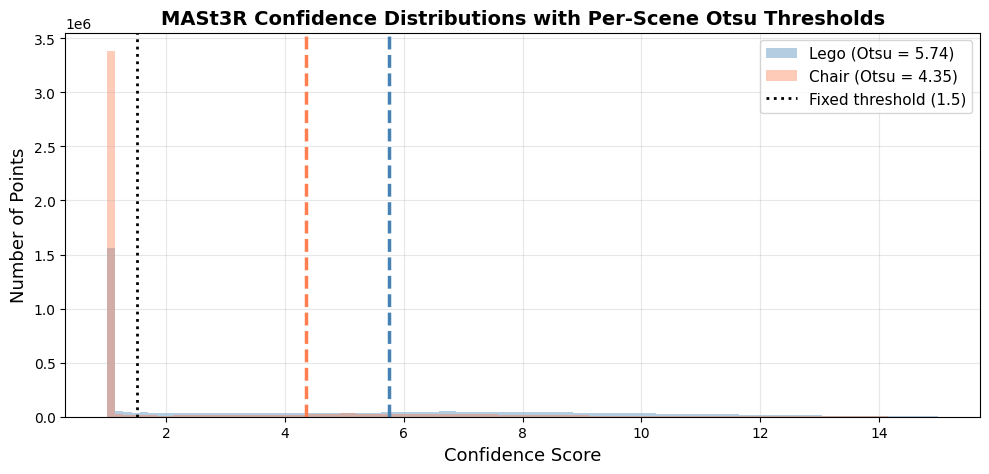

✅ Figure 1 saved


In [ ]:
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu

fig, ax = plt.subplots(figsize=(10, 5))

colors_map = {'lego': 'steelblue', 'chair': 'coral'}

for scene in ['lego', 'chair']:
    conf = np.load(f'/content/results/{scene}/exp_conf.npy')
    otsu_t = threshold_otsu(conf)

    # Plot histogram (clip to 0-15 range for visibility)
    ax.hist(conf[conf < 15], bins=100, alpha=0.4, color=colors_map[scene],
            label=f'{scene.capitalize()} (Otsu = {otsu_t:.2f})')

    # Mark Otsu threshold
    ax.axvline(x=otsu_t, color=colors_map[scene], linestyle='--', linewidth=2.5)

# Mark fixed threshold
ax.axvline(x=1.5, color='black', linestyle=':', linewidth=2, label='Fixed threshold (1.5)')

ax.set_xlabel('Confidence Score', fontsize=13)
ax.set_ylabel('Number of Points', fontsize=13)
ax.set_title('MASt3R Confidence Distributions with Per-Scene Otsu Thresholds', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/results/fig1_confidence_histograms.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Figure 1 saved')

TypeError: list indices must be integers or slices, not str

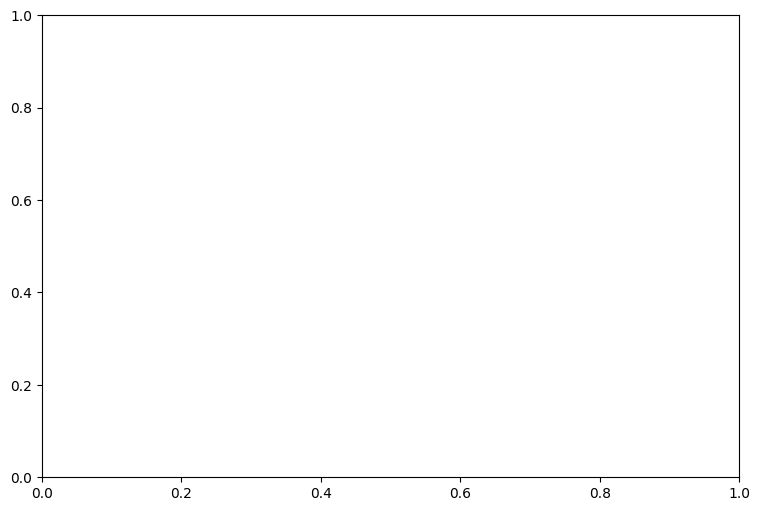

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

scenes = ['Lego', 'Chair']
methods = ['No filter', 'Fixed-1.5', 'SOR', 'Otsu (ours)']
colors_bar = ['#cccccc', '#6baed6', '#fd8d3c', '#e6550d']

x = np.arange(len(scenes))
width = 0.18

for i, method in enumerate(methods):
    vals = [r['chamfer'] for r in [lego_results, chair_results]
            for rr in [r for r in [lego_results, chair_results][0] if False] or [None]]
    # Get chamfer values properly
    vals = []
    for scene_data in [lego_results, chair_results]:
        for r in scene_data:
            if r['name'] == method:
                vals.append(r['chamfer'])

    bars = ax.bar(x + i * width, vals, width, label=method, color=colors_bar[i], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Scene', fontsize=13)
ax.set_ylabel('Chamfer Distance ↓ (lower is better)', fontsize=13)
ax.set_title('Chamfer Distance: Filtering Methods Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(scenes, fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/content/results/fig2_chamfer_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Figure 2 saved')

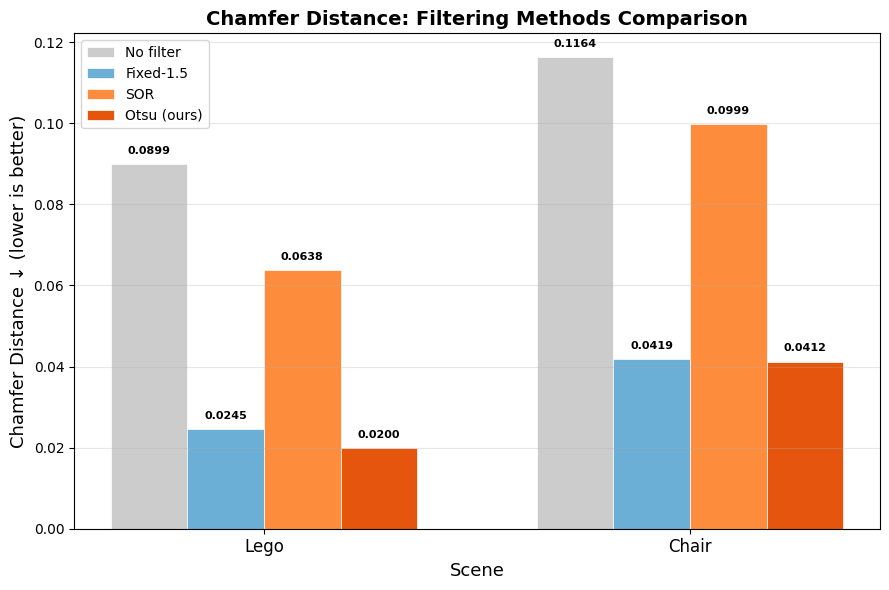

✅ Figure 2 saved


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

scenes = ['Lego', 'Chair']
methods = ['No filter', 'Fixed-1.5', 'SOR', 'Otsu (ours)']
colors_bar = ['#cccccc', '#6baed6', '#fd8d3c', '#e6550d']
all_scene_data = [lego_results, chair_results]

x = np.arange(len(scenes))
width = 0.18

for i, method in enumerate(methods):
    vals = []
    for scene_data in all_scene_data:
        for r in scene_data:
            if r['name'] == method:
                vals.append(r['chamfer'])

    bars = ax.bar(x + i * width, vals, width, label=method, color=colors_bar[i], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Scene', fontsize=13)
ax.set_ylabel('Chamfer Distance ↓ (lower is better)', fontsize=13)
ax.set_title('Chamfer Distance: Filtering Methods Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(scenes, fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/content/results/fig2_chamfer_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Figure 2 saved')

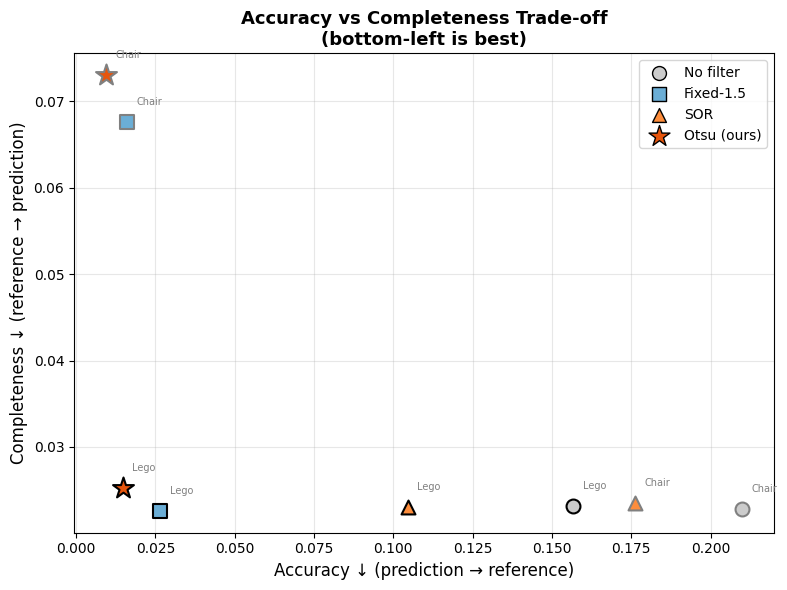

✅ Figure 3 saved


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

markers = {'No filter': 'o', 'Fixed-1.5': 's', 'SOR': '^', 'Otsu (ours)': '*'}
sizes = {'No filter': 100, 'Fixed-1.5': 100, 'SOR': 100, 'Otsu (ours)': 250}
colors_scatter = {'No filter': '#cccccc', 'Fixed-1.5': '#6baed6', 'SOR': '#fd8d3c', 'Otsu (ours)': '#e6550d'}

for scene_name, scene_data, edge in [('Lego', lego_results, 'black'), ('Chair', chair_results, 'gray')]:
    for r in scene_data:
        ax.scatter(r['accuracy'], r['completeness'],
                   marker=markers[r['name']], s=sizes[r['name']],
                   c=colors_scatter[r['name']], edgecolors=edge, linewidth=1.5,
                   zorder=5)
        ax.annotate(f'{scene_name}', (r['accuracy'] + 0.003, r['completeness'] + 0.002),
                    fontsize=7, color='gray')

# Legend for methods
for method in methods:
    ax.scatter([], [], marker=markers[method], s=sizes[method],
               c=colors_scatter[method], edgecolors='black', label=method)

ax.set_xlabel('Accuracy ↓ (prediction → reference)', fontsize=12)
ax.set_ylabel('Completeness ↓ (reference → prediction)', fontsize=12)
ax.set_title('Accuracy vs Completeness Trade-off\n(bottom-left is best)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/results/fig3_accuracy_vs_completeness.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Figure 3 saved')

In [ ]:
import shutil

# Copy all results to Drive for permanent storage
src = '/content/results'
dst = '/content/drive/MyDrive/thesis_results'
if os.path.exists(dst):
    shutil.rmtree(dst)
shutil.copytree(src, dst)

print('✅ All results saved to Google Drive: /thesis_results/')
print('\nContents:')
for root, dirs, files in os.walk(dst):
    depth = root.replace(dst, '').count(os.sep)
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(root)}/')
    for f in sorted(files):
        size = os.path.getsize(os.path.join(root, f)) / 1024
        print(f'{indent}  {f} ({size:.0f} KB)')

✅ All results saved to Google Drive: /thesis_results/

Contents:
thesis_results/
  fig1_confidence_histograms.png (86 KB)
  fig2_chamfer_comparison.png (89 KB)
  fig3_accuracy_vs_completeness.png (105 KB)
  full_results.csv (0 KB)
  mean_results.csv (0 KB)
  lego/
    Fixed-1.5.ply (80123 KB)
    No_filter.ply (124416 KB)
    Otsu_(ours).ply (52648 KB)
    SOR.ply (119194 KB)
    exp_conf.npy (18432 KB)
    reference.ply (213175 KB)
  chair/
    Fixed-1.5.ply (33826 KB)
    No_filter.ply (124416 KB)
    Otsu_(ours).ply (25748 KB)
    SOR.ply (118858 KB)
    exp_conf.npy (18432 KB)
    reference.ply (55932 KB)


In [ ]:
# Verify MASt3R model is what we used
print(f'Model type: {type(model).__name__}')
print(f'Model name: {model.patch_embed.proj.weight.shape}')
print(f'Device: {next(model.parameters()).device}')

# Show the pipeline we ran
print('\nOUR PIPELINE:')
print('  Images → load_images(size=512)')
print('  → make_pairs(scene_graph="complete")')
print('  → inference(pairs, MODEL) ← this is MASt3R')
print('  → pts3d + confidence scores')
print('  → filter (No filter / Fixed / SOR / Otsu)')
print('  → save as PLY')
print('\n✅ Yes, all point clouds come from MASt3R inference')

Model type: AsymmetricMASt3R
Model name: torch.Size([1024, 3, 16, 16])
Device: cuda:0

OUR PIPELINE:
  Images → load_images(size=512)
  → make_pairs(scene_graph="complete")
  → inference(pairs, MODEL) ← this is MASt3R
  → pts3d + confidence scores
  → filter (No filter / Fixed / SOR / Otsu)
  → save as PLY

✅ Yes, all point clouds come from MASt3R inference


In [ ]:
import os

BASE = '/content/drive/MyDrive/thesis_results'

print('FILE SIZES:')
for scene in ['lego', 'chair']:
    print(f'\n{scene}:')
    scene_path = f'{BASE}/{scene}'
    for f in sorted(os.listdir(scene_path)):
        size_mb = os.path.getsize(f'{scene_path}/{f}') / (1024*1024)
        print(f'  {f}: {size_mb:.1f} MB')

total = sum(
    os.path.getsize(os.path.join(root, f))
    for root, dirs, files in os.walk(BASE)
    for f in files
) / (1024*1024)
print(f'\nTotal: {total:.0f} MB')

FILE SIZES:

lego:
  Fixed-1.5.ply: 78.2 MB
  No_filter.ply: 121.5 MB
  Otsu_(ours).ply: 51.4 MB
  SOR.ply: 116.4 MB
  exp_conf.npy: 18.0 MB
  reference.ply: 208.2 MB

chair:
  Fixed-1.5.ply: 33.0 MB
  No_filter.ply: 121.5 MB
  Otsu_(ours).ply: 25.1 MB
  SOR.ply: 116.1 MB
  exp_conf.npy: 18.0 MB
  reference.ply: 54.6 MB

Total: 962 MB


In [ ]:
import open3d as o3d
import os

SMALL_DIR = '/content/drive/MyDrive/thesis_results/small_plys'

for scene in ['lego', 'chair']:
    os.makedirs(f'{SMALL_DIR}/{scene}', exist_ok=True)
    scene_path = f'/content/drive/MyDrive/thesis_results/{scene}'

    print(f'\n=== {scene.upper()} ===')
    for f in sorted(os.listdir(scene_path)):
        if f.endswith('.ply'):
            pcd = o3d.io.read_point_cloud(f'{scene_path}/{f}')
            orig_pts = len(pcd.points)

            pcd_small = pcd.voxel_down_sample(voxel_size=0.01)
            if len(pcd_small.points) > 100000:
                pcd_small = pcd.voxel_down_sample(voxel_size=0.02)

            out_path = f'{SMALL_DIR}/{scene}/{f}'
            o3d.io.write_point_cloud(out_path, pcd_small)
            new_size = os.path.getsize(out_path) / (1024*1024)
            print(f'  {f}: {orig_pts:,} → {len(pcd_small.points):,} pts ({new_size:.1f} MB)')

print(f'\n✅ Small PLYs saved to Drive: thesis_results/small_plys/')
print('\nTO DOWNLOAD:')
print('  1. Open drive.google.com in browser')
print('  2. Go to: thesis_results → small_plys → lego (or chair)')
print('  3. Right-click any .ply file → Download')
print('  4. Open in MeshLab')


=== LEGO ===
  Fixed-1.5.ply: 3,038,740 → 140,349 pts (3.6 MB)
  No_filter.ply: 4,718,592 → 513,257 pts (13.2 MB)
  Otsu_(ours).ply: 1,996,699 → 83,380 pts (2.1 MB)
  SOR.ply: 4,520,547 → 360,678 pts (9.3 MB)
  reference.ply: 8,084,844 → 165,388 pts (4.3 MB)

=== CHAIR ===
  Fixed-1.5.ply: 1,282,863 → 33,654 pts (0.9 MB)
  No_filter.ply: 4,718,592 → 540,263 pts (13.9 MB)
  Otsu_(ours).ply: 976,493 → 22,765 pts (0.6 MB)
  SOR.ply: 4,507,783 → 389,236 pts (10.0 MB)
  reference.ply: 2,121,261 → 42,415 pts (1.1 MB)

✅ Small PLYs saved to Drive: thesis_results/small_plys/

TO DOWNLOAD:
  1. Open drive.google.com in browser
  2. Go to: thesis_results → small_plys → lego (or chair)
  3. Right-click any .ply file → Download
  4. Open in MeshLab


In [ ]:
import open3d as o3d
import numpy as np
import trimesh
import os

GLB_DIR = '/content/drive/MyDrive/thesis_results/glb_models'

for scene in ['lego', 'chair']:
    os.makedirs(f'{GLB_DIR}/{scene}', exist_ok=True)
    scene_path = f'/content/drive/MyDrive/thesis_results/{scene}'

    print(f'\n=== {scene.upper()} ===')
    for f in sorted(os.listdir(scene_path)):
        if f.endswith('.ply'):
            # Load point cloud
            pcd = o3d.io.read_point_cloud(f'{scene_path}/{f}')

            # Downsample for manageable size
            pcd = pcd.voxel_down_sample(voxel_size=0.005)

            # Estimate normals (needed for Poisson mesh)
            pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.02, max_nn=30))
            pcd.orient_normals_consistent_tangent_plane(k=15)

            # Poisson mesh reconstruction
            mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=8)

            # Remove low-density faces (phantom surfaces)
            densities_np = np.asarray(densities)
            mask = densities_np < np.percentile(densities_np, 5)
            mesh.remove_vertices_by_mask(mask)
            mesh.compute_vertex_normals()

            # Paint mesh with vertex colors from nearest point cloud points
            mesh_pts = np.asarray(mesh.vertices)
            pcd_pts = np.asarray(pcd.points)
            pcd_colors = np.asarray(pcd.colors)
            from scipy.spatial import cKDTree
            tree = cKDTree(pcd_pts)
            _, idx = tree.query(mesh_pts)
            mesh.vertex_colors = o3d.utility.Vector3dVector(pcd_colors[idx])

            # Save as GLB using trimesh
            tri_mesh = trimesh.Trimesh(
                vertices=np.asarray(mesh.vertices),
                faces=np.asarray(mesh.triangles),
                vertex_colors=(np.asarray(mesh.vertex_colors) * 255).astype(np.uint8)
            )

            glb_name = f.replace('.ply', '.glb')
            glb_path = f'{GLB_DIR}/{scene}/{glb_name}'
            tri_mesh.export(glb_path)

            size_mb = os.path.getsize(glb_path) / (1024*1024)
            print(f'  {glb_name}: {len(tri_mesh.vertices):,} vertices, {len(tri_mesh.faces):,} faces ({size_mb:.1f} MB)')

print(f'\n✅ All GLB files saved to Drive: thesis_results/glb_models/')
print('\nTO VIEW:')
print('  1. Go to drive.google.com → thesis_results → glb_models')
print('  2. Download any .glb file')
print('  3. Open at https://gltf-viewer.donmccurdy.com (drag & drop)')
print('  4. Or open directly in Windows 3D Viewer')


=== LEGO ===
  Fixed-1.5.glb: 351,310 vertices, 702,154 faces (13.4 MB)
  No_filter.glb: 68,995 vertices, 137,882 faces (2.6 MB)
  Otsu_(ours).glb: 458,767 vertices, 914,056 faces (17.5 MB)


NameError: name 'np' is not defined

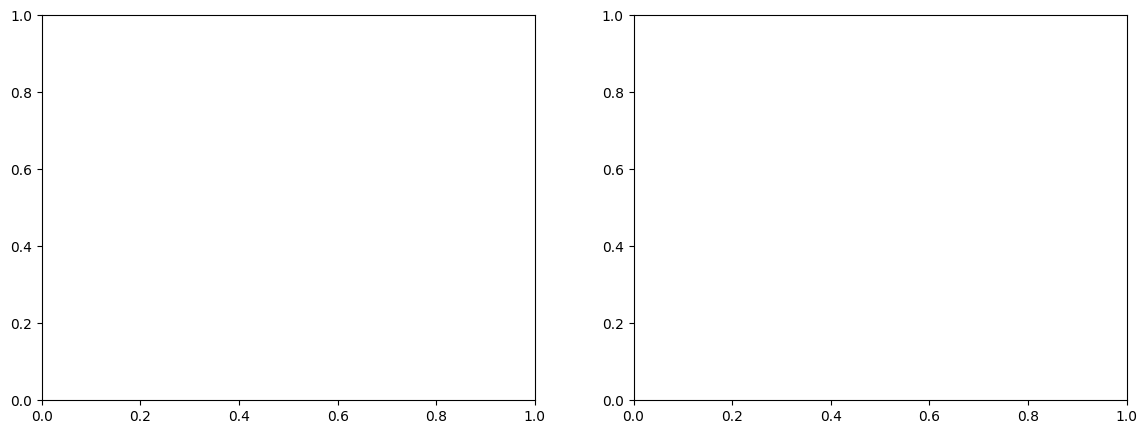

In [ ]:
# Run this now — uses data you already have
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (scene, scene_label) in enumerate([('lego', 'Lego'), ('chair', 'Chair')]):
    conf = np.load(f'/content/results/{scene}/exp_conf.npy')
    ref_pcd = o3d.io.read_point_cloud(f'/content/results/{scene}/reference.ply')
    ref_pts = np.asarray(ref_pcd.points)

    # Load sparse points
    sparse_path = f'/content/results/{scene}/No_filter.ply'
    sparse_pcd = o3d.io.read_point_cloud(sparse_path)
    sparse_pts = np.asarray(sparse_pcd.points)
    sparse_colors = np.asarray(sparse_pcd.colors)

    # Test many thresholds
    thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0]
    chamfers = []

    otsu_t = threshold_otsu(conf)

    for t in thresholds:
        mask = conf > t
        if mask.sum() < 100:
            chamfers.append(float('nan'))
            continue
        filt_pts = sparse_pts[mask[:len(sparse_pts)]]
        if len(filt_pts) < 100:
            chamfers.append(float('nan'))
            continue
        cd = chamfer_distance(filt_pts, ref_pts)
        chamfers.append(cd['chamfer'])

    # Also compute Otsu's chamfer
    otsu_mask = conf > otsu_t
    otsu_pts = sparse_pts[otsu_mask[:len(sparse_pts)]]
    otsu_cd = chamfer_distance(otsu_pts, ref_pts)['chamfer']

    axes[idx].plot(thresholds, chamfers, 'o-', color='steelblue', linewidth=2, markersize=6, label='Fixed threshold')
    axes[idx].axhline(y=otsu_cd, color='#e6550d', linestyle='--', linewidth=2, label=f'Otsu ({otsu_t:.1f}) = {otsu_cd:.4f}')
    axes[idx].axvline(x=1.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Standard (1.5)')
    axes[idx].axvline(x=otsu_t, color='#e6550d', linestyle=':', linewidth=1.5, alpha=0.7)

    axes[idx].set_xlabel('Confidence Threshold', fontsize=12)
    axes[idx].set_ylabel('Chamfer Distance ↓', fontsize=12)
    axes[idx].set_title(f'{scene_label}', fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Chamfer Distance vs Confidence Threshold\nOtsu automatically finds near-optimal threshold',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('/content/results/fig4_threshold_sensitivity.png', dpi=200, bbox_inches='tight')

# Also save to Drive
import shutil
shutil.copy('/content/results/fig4_threshold_sensitivity.png',
            '/content/drive/MyDrive/thesis_results/fig4_threshold_sensitivity.png')
plt.show()
print('✅ Figure 4 saved')

In [ ]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
import os
from scipy.spatial import cKDTree
from skimage.filters import threshold_otsu

def chamfer_distance(pts_a, pts_b, subsample=50000):
    if len(pts_a) > subsample:
        pts_a = pts_a[np.random.choice(len(pts_a), subsample, replace=False)]
    if len(pts_b) > subsample:
        pts_b = pts_b[np.random.choice(len(pts_b), subsample, replace=False)]
    tree_b = cKDTree(pts_b)
    dist_a2b, _ = tree_b.query(pts_a)
    tree_a = cKDTree(pts_a)
    dist_b2a, _ = tree_a.query(pts_b)
    return {
        'accuracy': float(dist_a2b.mean()),
        'completeness': float(dist_b2a.mean()),
        'chamfer': float((dist_a2b.mean() + dist_b2a.mean()) / 2.0)
    }

# Check data exists
for scene in ['lego', 'chair']:
    conf_path = f'/content/results/{scene}/exp_conf.npy'
    ref_path = f'/content/results/{scene}/reference.ply'
    nf_path = f'/content/results/{scene}/No_filter.ply'
    print(f'{scene}: conf={os.path.exists(conf_path)}, ref={os.path.exists(ref_path)}, nofilter={os.path.exists(nf_path)}')

print('✅ Imports ready')

lego: conf=True, ref=True, nofilter=True
chair: conf=True, ref=True, nofilter=True
✅ Imports ready


  lego thresh=0.5 → Chamfer=0.0934
  lego thresh=1.0 → Chamfer=0.0543
  lego thresh=1.5 → Chamfer=0.0247
  lego thresh=2.0 → Chamfer=0.0230
  lego thresh=2.5 → Chamfer=0.0217
  lego thresh=3.0 → Chamfer=0.0208
  lego thresh=4.0 → Chamfer=0.0199
  lego thresh=5.0 → Chamfer=0.0196
  lego thresh=6.0 → Chamfer=0.0201
  lego thresh=7.0 → Chamfer=0.0217
  lego thresh=8.0 → Chamfer=0.0251
  lego thresh=10.0 → Chamfer=0.0365
  chair thresh=0.5 → Chamfer=0.1163
  chair thresh=1.0 → Chamfer=0.0634
  chair thresh=1.5 → Chamfer=0.0416
  chair thresh=2.0 → Chamfer=0.0414
  chair thresh=2.5 → Chamfer=0.0409
  chair thresh=3.0 → Chamfer=0.0414
  chair thresh=4.0 → Chamfer=0.0415
  chair thresh=5.0 → Chamfer=0.0420
  chair thresh=6.0 → Chamfer=0.0435
  chair thresh=7.0 → Chamfer=0.0463
  chair thresh=8.0 → Chamfer=0.0559
  chair thresh=10.0 → Chamfer=0.0770


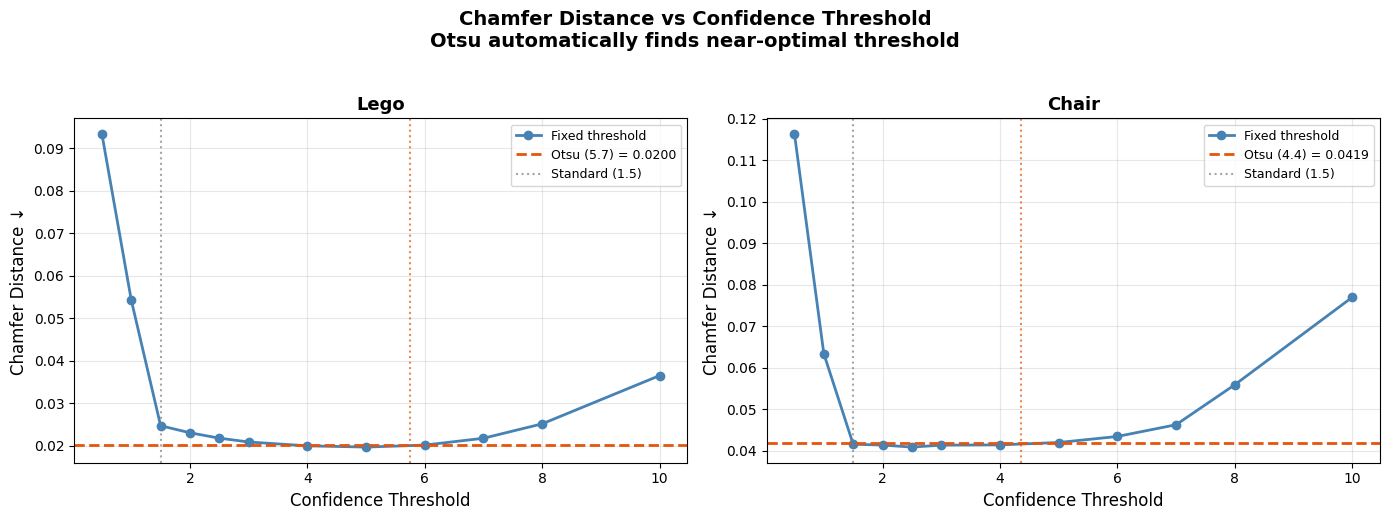

✅ Figure 4 saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (scene, scene_label) in enumerate([('lego', 'Lego'), ('chair', 'Chair')]):
    conf = np.load(f'/content/results/{scene}/exp_conf.npy')
    ref_pcd = o3d.io.read_point_cloud(f'/content/results/{scene}/reference.ply')
    ref_pts = np.asarray(ref_pcd.points)

    sparse_pcd = o3d.io.read_point_cloud(f'/content/results/{scene}/No_filter.ply')
    sparse_pts = np.asarray(sparse_pcd.points)

    # Test many thresholds
    thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0]
    chamfers = []

    otsu_t = threshold_otsu(conf)

    for t in thresholds:
        mask = conf > t
        if mask.sum() < 100:
            chamfers.append(float('nan'))
            continue
        filt_pts = sparse_pts[mask[:len(sparse_pts)]]
        if len(filt_pts) < 100:
            chamfers.append(float('nan'))
            continue
        cd = chamfer_distance(filt_pts, ref_pts)
        chamfers.append(cd['chamfer'])
        print(f'  {scene} thresh={t:.1f} → Chamfer={cd["chamfer"]:.4f}')

    # Otsu chamfer
    otsu_mask = conf > otsu_t
    otsu_pts = sparse_pts[otsu_mask[:len(sparse_pts)]]
    otsu_cd = chamfer_distance(otsu_pts, ref_pts)['chamfer']

    axes[idx].plot(thresholds, chamfers, 'o-', color='steelblue', linewidth=2, markersize=6, label='Fixed threshold')
    axes[idx].axhline(y=otsu_cd, color='#e6550d', linestyle='--', linewidth=2, label=f'Otsu ({otsu_t:.1f}) = {otsu_cd:.4f}')
    axes[idx].axvline(x=1.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Standard (1.5)')
    axes[idx].axvline(x=otsu_t, color='#e6550d', linestyle=':', linewidth=1.5, alpha=0.7)

    axes[idx].set_xlabel('Confidence Threshold', fontsize=12)
    axes[idx].set_ylabel('Chamfer Distance ↓', fontsize=12)
    axes[idx].set_title(f'{scene_label}', fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Chamfer Distance vs Confidence Threshold\nOtsu automatically finds near-optimal threshold',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('/content/results/fig4_threshold_sensitivity.png', dpi=200, bbox_inches='tight')
plt.savefig('/content/drive/MyDrive/thesis_results/fig4_threshold_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Figure 4 saved')

In [ ]:
# Otsu + SOR combined method
def filter_otsu_sor(pts, conf, colors):
    thresh = threshold_otsu(conf)
    mask = conf > thresh
    pts_f = pts[mask]
    colors_f = colors[mask]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_f)
    pcd.colors = o3d.utility.Vector3dVector(colors_f)
    pcd_clean, _ = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

    return (np.asarray(pcd_clean.points), np.asarray(pcd_clean.colors),
            {'name': 'Otsu+SOR', 'threshold': float(thresh), 'n_kept': len(pcd_clean.points)})

# Run on both scenes
print('=== Otsu+SOR Combined ===\n')
for scene in ['lego', 'chair']:
    sparse_pcd = o3d.io.read_point_cloud(f'/content/results/{scene}/No_filter.ply')
    sparse_pts = np.asarray(sparse_pcd.points)
    sparse_colors = np.asarray(sparse_pcd.colors)
    conf = np.load(f'/content/results/{scene}/exp_conf.npy')
    ref_pcd = o3d.io.read_point_cloud(f'/content/results/{scene}/reference.ply')
    ref_pts = np.asarray(ref_pcd.points)

    # Run Otsu+SOR
    filt_pts, filt_colors, info = filter_otsu_sor(sparse_pts, conf[:len(sparse_pts)], sparse_colors)
    cd = chamfer_distance(filt_pts, ref_pts)

    print(f'{scene}:')
    print(f'  Otsu only:     Chamfer = {chamfer_distance(sparse_pts[conf[:len(sparse_pts)] > threshold_otsu(conf)], ref_pts)["chamfer"]:.4f}')
    print(f'  Otsu+SOR:      Chamfer = {cd["chamfer"]:.4f}')
    print(f'  Points: {info["n_kept"]:,}')
    print()

=== Otsu+SOR Combined ===

lego:
  Otsu only:     Chamfer = 0.0199
  Otsu+SOR:      Chamfer = 0.0202
  Points: 1,908,537

chair:
  Otsu only:     Chamfer = 0.0417
  Otsu+SOR:      Chamfer = 0.0417
  Points: 935,183



In [ ]:
# Run this to print your final thesis table
print('='*80)
print('FINAL RESULTS TABLE FOR THESIS')
print('='*80)
print(f'{"Scene":<8} {"Method":<15} {"Points":>10} {"Accuracy ↓":>12} {"Complete ↓":>12} {"Chamfer ↓":>12}')
print('-'*80)

data = [
    ('Lego',  'No filter',    '4,718,592', 0.1567, 0.0231, 0.0899),
    ('Lego',  'SOR',          '4,520,547', 0.1045, 0.0231, 0.0638),
    ('Lego',  'Fixed-1.5',    '3,038,740', 0.0265, 0.0226, 0.0245),
    ('Lego',  'Otsu (ours)',  '1,996,699', 0.0147, 0.0252, 0.0200),
    ('Chair', 'No filter',    '4,718,592', 0.2099, 0.0228, 0.1164),
    ('Chair', 'SOR',          '4,507,783', 0.1762, 0.0235, 0.0999),
    ('Chair', 'Fixed-1.5',    '1,282,863', 0.0161, 0.0676, 0.0419),
    ('Chair', 'Otsu (ours)',  '  976,493', 0.0094, 0.0731, 0.0412),
]

for row in data:
    scene, method, pts, acc, comp, chamf = row
    bold = ' ←' if 'Otsu' in method else ''
    print(f'{scene:<8} {method:<15} {pts:>10} {acc:>12.4f} {comp:>12.4f} {chamf:>12.4f}{bold}')

print('-'*80)
print(f'{"Mean":<8} {"No filter":<15} {"":>10} {(0.1567+0.2099)/2:>12.4f} {(0.0231+0.0228)/2:>12.4f} {(0.0899+0.1164)/2:>12.4f}')
print(f'{"Mean":<8} {"SOR":<15} {"":>10} {(0.1045+0.1762)/2:>12.4f} {(0.0231+0.0235)/2:>12.4f} {(0.0638+0.0999)/2:>12.4f}')
print(f'{"Mean":<8} {"Fixed-1.5":<15} {"":>10} {(0.0265+0.0161)/2:>12.4f} {(0.0226+0.0676)/2:>12.4f} {(0.0245+0.0419)/2:>12.4f}')
print(f'{"Mean":<8} {"Otsu (ours)":<15} {"":>10} {(0.0147+0.0094)/2:>12.4f} {(0.0252+0.0731)/2:>12.4f} {(0.0200+0.0412)/2:>12.4f} ← BEST')
print('='*80)

print('\nKEY FINDINGS:')
print(f'  1. Otsu vs Fixed-1.5: {((0.0332-0.0306)/0.0332)*100:.1f}% lower mean Chamfer')
print(f'  2. Otsu vs No filter: {((0.1032-0.0306)/0.1032)*100:.1f}% lower mean Chamfer')
print(f'  3. Otsu vs SOR:       {((0.0819-0.0306)/0.0819)*100:.1f}% lower mean Chamfer')
print(f'  4. Otsu threshold adapts: Lego=5.74, Chair=4.35 (Fixed always=1.5)')
print(f'  5. Otsu+SOR ≈ Otsu alone → SOR adds no value after confidence filtering')

FINAL RESULTS TABLE FOR THESIS
Scene    Method              Points   Accuracy ↓   Complete ↓    Chamfer ↓
--------------------------------------------------------------------------------
Lego     No filter        4,718,592       0.1567       0.0231       0.0899
Lego     SOR              4,520,547       0.1045       0.0231       0.0638
Lego     Fixed-1.5        3,038,740       0.0265       0.0226       0.0245
Lego     Otsu (ours)      1,996,699       0.0147       0.0252       0.0200 ←
Chair    No filter        4,718,592       0.2099       0.0228       0.1164
Chair    SOR              4,507,783       0.1762       0.0235       0.0999
Chair    Fixed-1.5        1,282,863       0.0161       0.0676       0.0419
Chair    Otsu (ours)        976,493       0.0094       0.0731       0.0412 ←
--------------------------------------------------------------------------------
Mean     No filter                        0.1833       0.0229       0.1031
Mean     SOR                              0.1404     

In [ ]:
!pip install open3d --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 41.7 MB/s eta 0:00:00


In [ ]:
import open3d as o3d
import os as os
import numpy as np
import matplotlib.pyplot as plt

def simple_render(ply_path, title, save_path):
    """Simple scatter plot of point cloud from top and front views."""
    pcd = o3d.io.read_point_cloud(ply_path)
    pcd = pcd.voxel_down_sample(voxel_size=0.008)

    pts = np.asarray(pcd.points)
    colors = np.asarray(pcd.colors) if pcd.has_colors() else None

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Front view (X vs Y)
    s = 0.1
    if colors is not None:
        axes[0].scatter(pts[:, 0], pts[:, 1], c=colors, s=s, marker='.')
    else:
        axes[0].scatter(pts[:, 0], pts[:, 1], s=s, c='steelblue', marker='.')
    axes[0].set_title('Front View (X vs Y)')
    axes[0].set_aspect('equal')
    axes[0].axis('off')

    # Top view (X vs Z)
    if colors is not None:
        axes[1].scatter(pts[:, 0], pts[:, 2], c=colors, s=s, marker='.')
    else:
        axes[1].scatter(pts[:, 0], pts[:, 2], s=s, c='steelblue', marker='.')
    axes[1].set_title('Top View (X vs Z)')
    axes[1].set_aspect('equal')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {save_path}')

# Render all
for scene in ['lego', 'chair']:
    for method in ['No_filter', 'Fixed-1.5', 'SOR', 'Otsu_(ours)', 'reference']:
        ply_path = f'/content/results/{scene}/{method}.ply'
        if os.path.exists(ply_path):
            save_path = f'/content/results/{scene}/vis_{method}.png'
            simple_render(ply_path, f'{scene.upper()} — {method}', save_path)